# Rabi result plots (continued)

Continuation of `rabi_result.ipynb` -- that notebook grew too large to
re-read (offset/limit aren't respected for `.ipynb` files once the
rendered content exceeds the tool's token cap), so further in-progress
`run-repeat` median plots go here instead. Same `DATA_DIR`/conventions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import re

DATA_DIR = "D:/rabi"

## measurement25: per-point median across repeats

`run-repeat` batch, 5 repeats completed. Auto-discovers completed
repeats, then takes the per-point MEDIAN of X/Y across them -- same
outlier-robust approach as `measurement22`/`measurement24`'s median cells
in `rabi_result.ipynb` (a repeat with a wild value at one point gets
outvoted there without needing to drop the whole repeat). `freq_hz=2840`
MHz, `pre_us=2.0` (longer than the other recent runs), `coil_current_a=
2.5` A, `constant_shot_period=1`, `phase_deg=-60.0`.

found 4 completed repeats: [0, 1, 3, 4]
taking median of 4/4 repeats
freq_hz=2840000000.0
drive_power_dbm=0.0
n_reps=250
laser_us=5.0
pre_us=2.0
post_us=1.0
time_constant_s=0.1
settle_periods=5.0
settle_time_constants=9.0
sensitivity_v=0.001
phase_deg=-60.0
coil_current_a=2.5
constant_shot_period=1
pad_min_us=0.1

22/60 points had at least one repeat >5x the per-point median absolute deviation away (median-rejected)


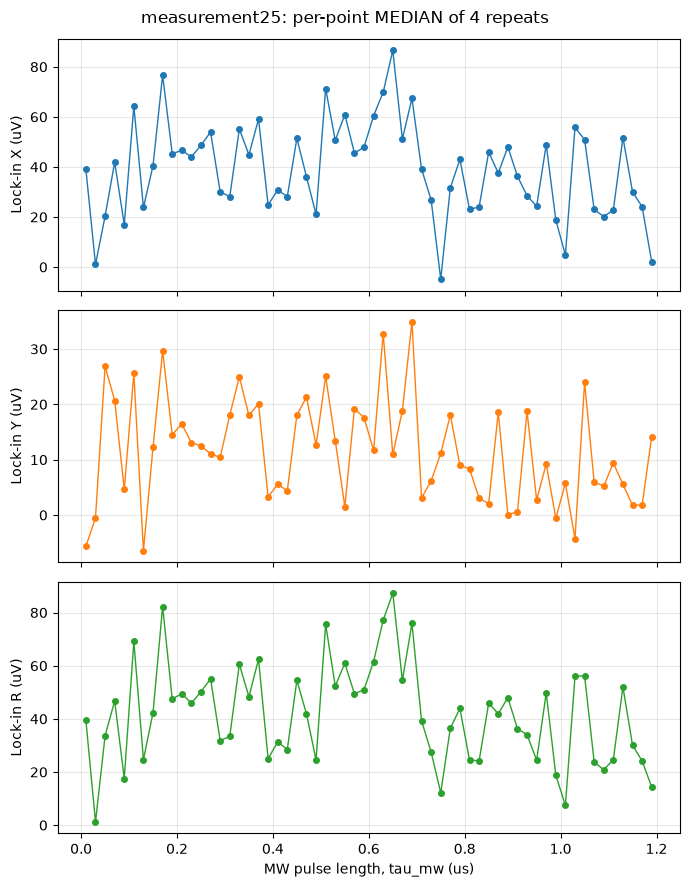

In [2]:
name25 = "measurement25"
run_path25 = f"{DATA_DIR}/{name25}"

repeat_indices25 = sorted(
    int(re.search(r"_repeat(\d+)_rabi_x\.npy$", p).group(1))
    for p in glob.glob(f"{run_path25}/{name25}_repeat*_rabi_x.npy")
)
print(f"found {len(repeat_indices25)} completed repeats: {repeat_indices25}")

mw_us_ref25 = None
xs25, ys25 = [], []
for i in repeat_indices25:
    prefix = f"{run_path25}/{name25}_repeat{i}"
    mw_us_i = np.load(f"{prefix}_rabi_mw_us.npy")
    if mw_us_ref25 is None:
        mw_us_ref25 = mw_us_i
    elif len(mw_us_i) != len(mw_us_ref25) or not np.allclose(mw_us_i, mw_us_ref25):
        print(f"  repeat{i}: mw_us grid mismatch ({len(mw_us_i)} vs {len(mw_us_ref25)} points) -- excluded")
        continue
    xs25.append(np.load(f"{prefix}_rabi_x.npy"))
    ys25.append(np.load(f"{prefix}_rabi_y.npy"))

print(f"taking median of {len(xs25)}/{len(repeat_indices25)} repeats")

with open(f"{run_path25}/{name25}_repeat0_rabi_metadata.txt") as fh:
    print(fh.read())

xs25_arr = np.array(xs25)
ys25_arr = np.array(ys25)

x_med25 = np.median(xs25_arr, axis=0)
y_med25 = np.median(ys25_arr, axis=0)
r_med25 = np.sqrt(x_med25**2 + y_med25**2)

mad_x25 = np.median(np.abs(xs25_arr - x_med25), axis=0)
n_flagged25 = np.sum(np.any(np.abs(xs25_arr - x_med25) > 5 * (mad_x25 + 1e-12), axis=0))
print(f"{n_flagged25}/{len(x_med25)} points had at least one repeat >5x the "
      f"per-point median absolute deviation away (median-rejected)")

fig, axes = plt.subplots(3, 1, figsize=(7, 9), sharex=True)
axes[0].plot(mw_us_ref25, x_med25 * 1e6, "o-", ms=4, lw=1, color="tab:blue")
axes[1].plot(mw_us_ref25, y_med25 * 1e6, "o-", ms=4, lw=1, color="tab:orange")
axes[2].plot(mw_us_ref25, r_med25 * 1e6, "o-", ms=4, lw=1, color="tab:green")

axes[0].set_ylabel("Lock-in X (uV)")
axes[1].set_ylabel("Lock-in Y (uV)")
axes[2].set_ylabel("Lock-in R (uV)")
axes[2].set_xlabel("MW pulse length, tau_mw (us)")
for ax in axes:
    ax.grid(alpha=0.3)

fig.suptitle(f"{name25}: per-point MEDIAN of {len(xs25)} repeats")
plt.tight_layout()
plt.show()

## measurement25: per-point mean (average) across repeats, for comparison

Same repeats as the median cell above, but plain elementwise mean of
X/Y (then R from the averaged X/Y) -- shows how much the outlier
rejection actually changes the result vs. just averaging everything.

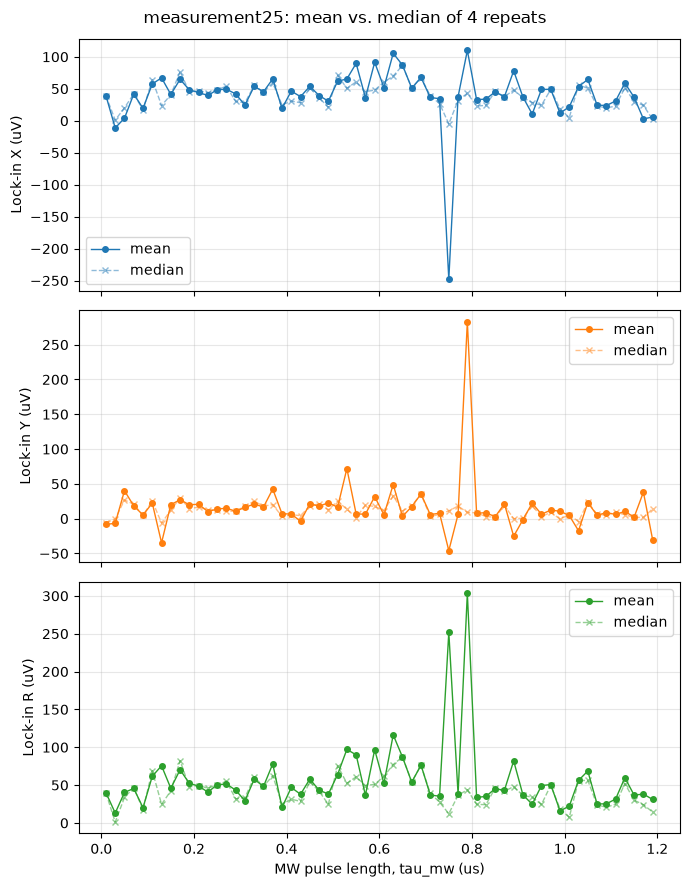

In [3]:
x_avg25 = np.mean(xs25_arr, axis=0)
y_avg25 = np.mean(ys25_arr, axis=0)
r_avg25 = np.sqrt(x_avg25**2 + y_avg25**2)

fig, axes = plt.subplots(3, 1, figsize=(7, 9), sharex=True)
axes[0].plot(mw_us_ref25, x_avg25 * 1e6, "o-", ms=4, lw=1, color="tab:blue", label="mean")
axes[1].plot(mw_us_ref25, y_avg25 * 1e6, "o-", ms=4, lw=1, color="tab:orange", label="mean")
axes[2].plot(mw_us_ref25, r_avg25 * 1e6, "o-", ms=4, lw=1, color="tab:green", label="mean")
axes[0].plot(mw_us_ref25, x_med25 * 1e6, "x--", ms=5, lw=1, color="tab:blue", alpha=0.5, label="median")
axes[1].plot(mw_us_ref25, y_med25 * 1e6, "x--", ms=5, lw=1, color="tab:orange", alpha=0.5, label="median")
axes[2].plot(mw_us_ref25, r_med25 * 1e6, "x--", ms=5, lw=1, color="tab:green", alpha=0.5, label="median")

axes[0].set_ylabel("Lock-in X (uV)")
axes[1].set_ylabel("Lock-in Y (uV)")
axes[2].set_ylabel("Lock-in R (uV)")
axes[2].set_xlabel("MW pulse length, tau_mw (us)")
for ax in axes:
    ax.grid(alpha=0.3)
    ax.legend()

fig.suptitle(f"{name25}: mean vs. median of {len(xs25)} repeats")
plt.tight_layout()
plt.show()